In [82]:
import PreProcessedData
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [83]:
def statistical_analysis (data):
    data_frame = pd.DataFrame(data)
    numeric_cols = data_frame[['affected_area', 'temperature', 'irradiance', 'Voc', 'Isc']]
    categorical_data = data_frame[["pv_module_type", "hotspot", "birddrop", "soiling", "junction_box"]]

    frequency_relatives = categorical_data.apply(lambda col: col.value_counts(normalize=True))

    print(f"Means: \n{numeric_cols.mean().round(4)}")
    print(f"STDs: \n{numeric_cols.std().round(4)}")

    for col in categorical_data:
        print(f"Frequência relativa de '{col}':")
        freq_no_na = frequency_relatives[col].dropna()
        print(freq_no_na.round(4))
        print()
    print("-" * 50)

In [84]:
data = PreProcessedData.load_data("pv_module_efficiency_dataset.csv")
statistical_analysis (data)

Means: 
affected_area      0.1205
temperature       24.9879
irradiance       999.8197
Voc               44.9043
Isc               10.0066
dtype: float64
STDs: 
affected_area     0.1296
temperature       4.9973
irradiance       99.7361
Voc               1.0691
Isc               1.5713
dtype: float64
Frequência relativa de 'pv_module_type':
HJT          0.2506
Mono-PERC    0.2511
Poly-BSF     0.2497
Thin-Film    0.2486
Name: pv_module_type, dtype: float64

Frequência relativa de 'hotspot':
Mild Hotspot      0.2682
None              0.4668
Severe Hotspot    0.2650
Name: hotspot, dtype: float64

Frequência relativa de 'birddrop':
Few     0.267
Many    0.266
None    0.467
Name: birddrop, dtype: float64

Frequência relativa de 'soiling':
High        0.1997
Low         0.2019
Moderate    0.2024
None        0.3960
Name: soiling, dtype: float64

Frequência relativa de 'junction_box':
None       0.5994
Visible    0.4006
Name: junction_box, dtype: float64

----------------------------------------

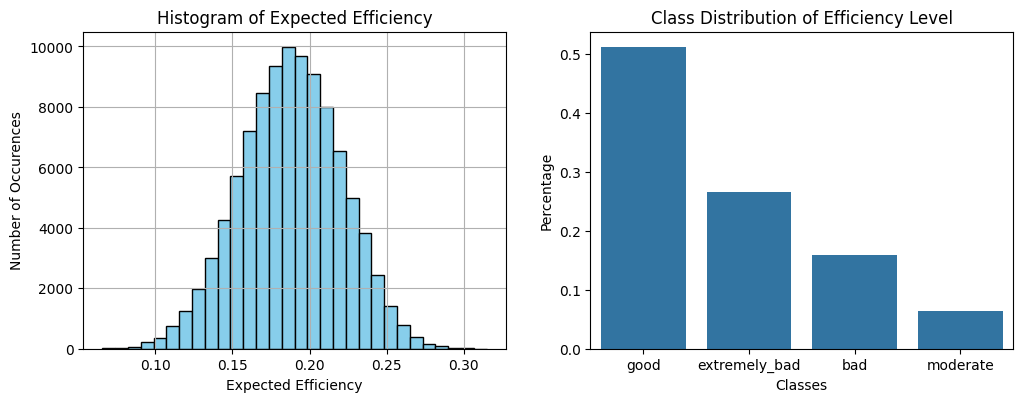

<Figure size 640x480 with 0 Axes>

In [85]:
class_counts = data['efficiency_level'].value_counts(normalize=True)
plt.figure(figsize=(12, 14))

plt.subplot(3, 2, 1)
plt.hist(data['expected_efficiency'], bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of Expected Efficiency')
plt.xlabel('Expected Efficiency')
plt.ylabel('Number of Occurences')
plt.grid(True)

plt.subplot(3, 2, 2)
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title('Class Distribution of Efficiency Level')
plt.xlabel('Classes')
plt.ylabel('Percentage')
plt.show()
plt.tight_layout()

In [86]:
X_train, X_validation, X_test, y_train_1, y_validation_1, y_test_1,  y_train_2, y_validation_2, y_test_2 = PreProcessedData.split_data(data, "expected_efficiency", "efficiency_level", 0.3, 42)

data_train= pd.concat([X_train, y_train_1, y_train_2], axis=1)
data_val= pd.concat([X_validation, y_validation_1, y_validation_2], axis=1)
data_test= pd.concat([X_test, y_test_1, y_test_2], axis=1)
statistical_analysis (data_train)
statistical_analysis (data_val)
statistical_analysis (data_test)

Means: 
affected_area      0.1206
temperature       24.9717
irradiance       999.7738
Voc               44.9016
Isc               10.0030
dtype: float64
STDs: 
affected_area     0.1297
temperature       4.9806
irradiance       99.6888
Voc               1.0685
Isc               1.5709
dtype: float64
Frequência relativa de 'pv_module_type':
HJT          0.2487
Mono-PERC    0.2515
Poly-BSF     0.2495
Thin-Film    0.2503
Name: pv_module_type, dtype: float64

Frequência relativa de 'hotspot':
Mild Hotspot      0.2695
None              0.4668
Severe Hotspot    0.2638
Name: hotspot, dtype: float64

Frequência relativa de 'birddrop':
Few     0.2670
Many    0.2662
None    0.4668
Name: birddrop, dtype: float64

Frequência relativa de 'soiling':
High        0.1996
Low         0.2017
Moderate    0.2031
None        0.3957
Name: soiling, dtype: float64

Frequência relativa de 'junction_box':
None       0.5998
Visible    0.4002
Name: junction_box, dtype: float64

-------------------------------------

In [87]:
import pandas as pd

# Step 1: Create DataFrame for Means and STDs
means_data = {
    "Dataset 1": [0.1206, 24.9717, 999.7738, 44.9016, 10.0030],
    "Dataset 2": [0.1215, 25.0690, 1000.0983, 44.9038, 10.0060],
    "Dataset 3": [0.1195, 24.9827, 999.7553, 44.9172, 10.0236]
}
stds_data = {
    "Dataset 1": [0.1297, 4.9806, 99.6888, 1.0685, 1.5709],
    "Dataset 2": [0.1302, 5.0461, 100.0762, 1.0641, 1.5758],
    "Dataset 3": [0.1284, 5.0254, 99.6222, 1.0770, 1.5685]
}
features = ["affected_area", "temperature", "irradiance", "Voc", "Isc"]

means_df = pd.DataFrame(means_data, index=features)
stds_df = pd.DataFrame(stds_data, index=features)

# Step 2: Create DataFrame for Frequencies
pv_module_type = pd.DataFrame({
    "Dataset 1": [0.2487, 0.2515, 0.2495, 0.2503],
    "Dataset 2": [0.2512, 0.2519, 0.2536, 0.2433],
    "Dataset 3": [0.2583, 0.2485, 0.2471, 0.2461]
}, index=["HJT", "Mono-PERC", "Poly-BSF", "Thin-Film"])

hotspot = pd.DataFrame({
    "Dataset 1": [0.2695, 0.4668, 0.2638],
    "Dataset 2": [0.2676, 0.4642, 0.2682],
    "Dataset 3": [0.2626, 0.4698, 0.2676]
}, index=["Mild Hotspot", "None", "Severe Hotspot"])

birddrop = pd.DataFrame({
    "Dataset 1": [0.2670, 0.2662, 0.4668],
    "Dataset 2": [0.2651, 0.2667, 0.4681],
    "Dataset 3": [0.2688, 0.2645, 0.4667]
}, index=["Few", "Many", "None"])

soiling = pd.DataFrame({
    "Dataset 1": [0.1996, 0.2017, 0.2031, 0.3957],
    "Dataset 2": [0.2005, 0.2035, 0.2017, 0.3943],
    "Dataset 3": [0.1993, 0.2013, 0.1997, 0.3996]
}, index=["High", "Low", "Moderate", "None"])

junction_box = pd.DataFrame({
    "Dataset 1": [0.5998, 0.4002],
    "Dataset 2": [0.5998, 0.4002],
    "Dataset 3": [0.5972, 0.4028]
}, index=["None", "Visible"])

# Display tables
print("Means:")
print(means_df)
print("\nSTDs:")
print(stds_df)
print("\nFrequency of 'pv_module_type':")
print(pv_module_type)
print("\nFrequency of 'hotspot':")
print(hotspot)
print("\nFrequency of 'birddrop':")
print(birddrop)
print("\nFrequency of 'soiling':")
print(soiling)
print("\nFrequency of 'junction_box':")
print(junction_box)

Means:
               Dataset 1  Dataset 2  Dataset 3
affected_area     0.1206     0.1215     0.1195
temperature      24.9717    25.0690    24.9827
irradiance      999.7738  1000.0983   999.7553
Voc              44.9016    44.9038    44.9172
Isc              10.0030    10.0060    10.0236

STDs:
               Dataset 1  Dataset 2  Dataset 3
affected_area     0.1297     0.1302     0.1284
temperature       4.9806     5.0461     5.0254
irradiance       99.6888   100.0762    99.6222
Voc               1.0685     1.0641     1.0770
Isc               1.5709     1.5758     1.5685

Frequency of 'pv_module_type':
           Dataset 1  Dataset 2  Dataset 3
HJT           0.2487     0.2512     0.2583
Mono-PERC     0.2515     0.2519     0.2485
Poly-BSF      0.2495     0.2536     0.2471
Thin-Film     0.2503     0.2433     0.2461

Frequency of 'hotspot':
                Dataset 1  Dataset 2  Dataset 3
Mild Hotspot       0.2695     0.2676     0.2626
None               0.4668     0.4642     0.4698
Severe

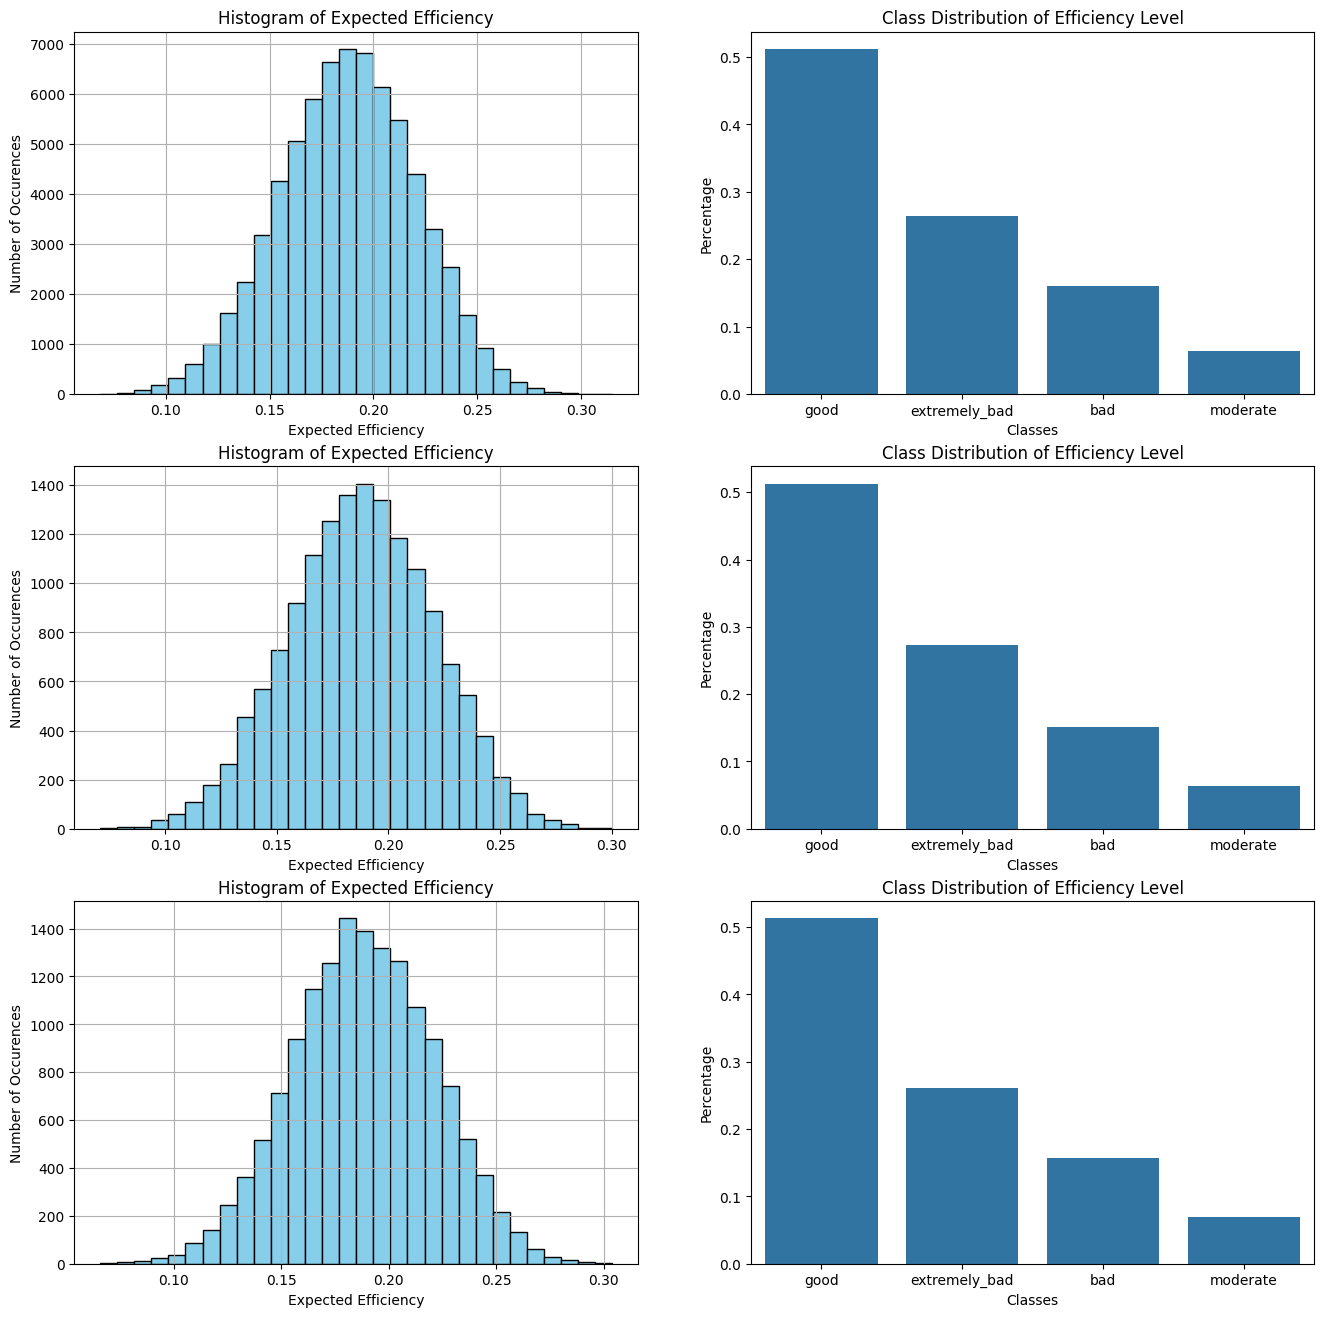

<Figure size 640x480 with 0 Axes>

In [88]:
class_counts_train = data_train['efficiency_level'].value_counts(normalize=True)
class_counts_val = data_val['efficiency_level'].value_counts(normalize=True)
class_counts_test = data_test['efficiency_level'].value_counts(normalize=True)

plt.figure(figsize=(16, 16))

plt.subplot(3, 2, 1)
plt.hist(data_train['expected_efficiency'], bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of Expected Efficiency')
plt.xlabel('Expected Efficiency')
plt.ylabel('Number of Occurences')
plt.grid(True)

plt.subplot(3, 2, 2)
sns.barplot(x=class_counts_train.index, y=class_counts_train.values)
plt.title('Class Distribution of Efficiency Level')
plt.xlabel('Classes')
plt.ylabel('Percentage')

plt.subplot(3, 2, 3)
plt.hist(data_val['expected_efficiency'], bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of Expected Efficiency')
plt.xlabel('Expected Efficiency')
plt.ylabel('Number of Occurences')
plt.grid(True)

plt.subplot(3, 2, 4)
sns.barplot(x=class_counts_val.index, y=class_counts_val.values)
plt.title('Class Distribution of Efficiency Level')
plt.xlabel('Classes')
plt.ylabel('Percentage')

plt.subplot(3, 2, 5)
plt.hist(data_test['expected_efficiency'], bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of Expected Efficiency')
plt.xlabel('Expected Efficiency')
plt.ylabel('Number of Occurences')
plt.grid(True)

plt.subplot(3, 2, 6)
sns.barplot(x=class_counts_test.index, y=class_counts_test.values)
plt.title('Class Distribution of Efficiency Level')
plt.xlabel('Classes')
plt.ylabel('Percentage')
plt.show()
plt.tight_layout()